In [25]:
from pathlib import Path

from lib.fs.get_script_name import get_name
from lib.fs.project_config import REPO_ROOT
from plotting import plot_config

script_name = get_name()
out_dir = REPO_ROOT / "figures" / script_name

import matplotlib.pyplot as plt
import numpy as np
import h5py

In [26]:
SUBJECT_ID = "sub-NDARINVAG388HJL"
FILE_SUFFIX = "_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5"

# FILE_DIR = Path("/cluster/work/ianpe/masters_thesis/bids_processed_consolidated_data") # IDUN
FILE_DIR = Path("/Users/ipeglin/Documents/masters_thesis/bids_processed_consolidated_data") # LOCAL
FILE_PATH = FILE_DIR / SUBJECT_ID / f"{SUBJECT_ID}{FILE_SUFFIX}"

ROI_IDX = 2 # lAMY-rh

In [27]:
out_dir.mkdir(parents=True, exist_ok=True)

In [28]:
with h5py.File(FILE_PATH, 'r') as f:
  wb_group = f['04mvmd/full_run_std']
  
  num_iterations = wb_group.attrs.get("num_iterations", None)
  
  modes = np.asarray(wb_group['modes'])
  num_modes, num_channels, num_samples = modes.shape
  
  center_freqs = np.asarray(wb_group['center_frequencies'])
  freq_traces = np.asarray(wb_group['frequency_traces'])
  

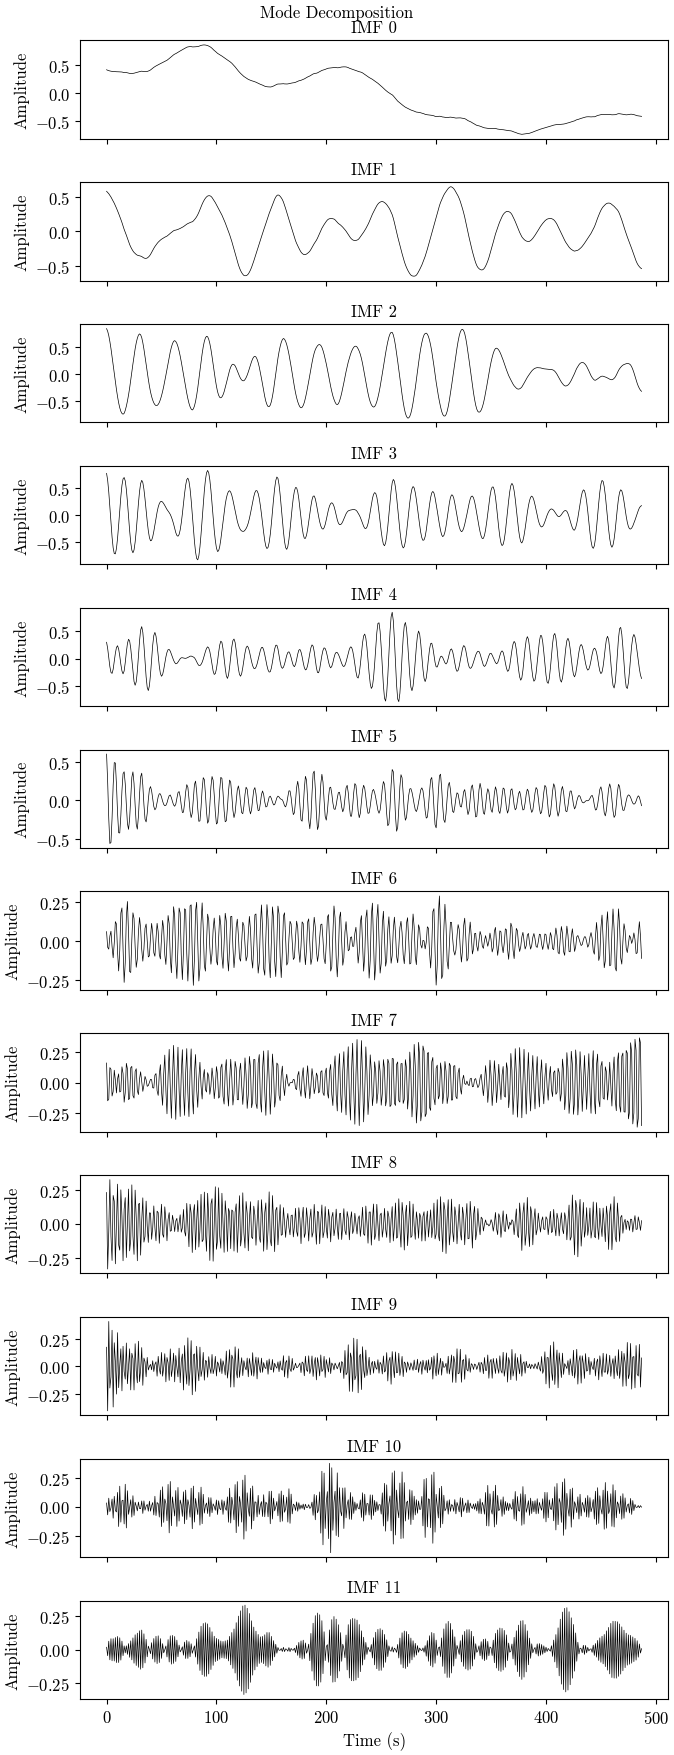

In [29]:
import math

# Set font size to 12 for LaTeX (no scaling issues if width is set to typical \linewidth)
plt.rcParams.update({'font.size': 12})

# plotting first ROI
ROI_IDX = 0

# Revert to 1 column to maximize the horizontal resolution limit of a standard page
num_cols = 1
num_rows = num_modes

# A width of 7.0 inches is standard for \linewidth. 
# We reduce the height per plot slightly to avoid the figure becoming too tall overall.
fig, ax = plt.subplots(num_rows, num_cols, 
 figsize=(7.0, 1.5 * num_rows),
 layout='tight',
 sharex=True)

# Ensure ax is an iterable array
axes = np.atleast_1d(ax)

fig.suptitle("Mode Decomposition")

for i in range(num_modes):
    # Set traces to black, and make the line thinner (e.g., 0.5) to untangle high-frequency oscillations
    axes[i].plot(modes[i, ROI_IDX, :], color='k', linewidth=0.5)
    axes[i].set_ylabel("Amplitude")
    axes[i].set_title(f"IMF {i}")

# Only set the x-label on the bottom-most plot
axes[-1].set_xlabel("Time (s)")

# Use tight_layout with padding to remove wedge margins while dodging the super title
plt.savefig(out_dir / "timeseries_modes.pdf")

In [30]:
from scipy.signal import hilbert

TR = 0.8 # seconds
fs = 1.0 / TR

# Compute analytic signal per mode for ROI
# modes shape: (num_modes, num_channels, num_samples)
roi_modes = modes[:, ROI_IDX, :]

# Modes are real-valued, use hilbert to get analytic signal
analytic_signal = hilbert(roi_modes, axis=1)

amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal), axis=1)

# Compute instantaneous natural frequency in Hz
# Diff gives radians/sample (angular freq). Div by 2pi -> cycles/sample. Mult by fs -> Hz.
instantaneous_frequency_hz = (np.diff(instantaneous_phase, axis=1) / (2.0 * np.pi)) * fs
# Pad to match num_samples
instantaneous_frequency_hz = np.pad(instantaneous_frequency_hz, ((0, 0), (0, 1)), mode='edge')

# Get final center frequencies and convert to Hz 
# (assuming mvmd output normalized freq 0 to 0.5)
cf_final = center_freqs[-1] if center_freqs.ndim > 1 else center_freqs
cf_hz = cf_final * fs

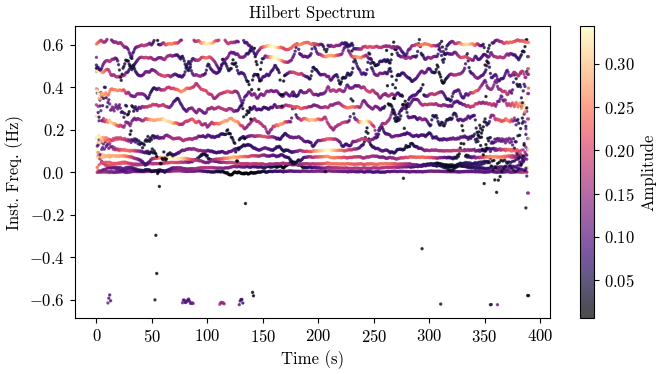

In [31]:
# Plot Hilbert Spectrum
fig, ax = plt.subplots(figsize=(7.0, 4.0), layout='tight')

time_s = np.arange(num_samples) * TR
for i in range(num_modes):
    im = ax.scatter(time_s, instantaneous_frequency_hz[i], c=amplitude_envelope[i], 
                    cmap='magma', s=2, alpha=0.7)

ax.set_ylabel("Inst. Freq. (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("Hilbert Spectrum")
fig.colorbar(im, ax=ax, label="Amplitude")

plt.savefig(out_dir / "hilbert_spectrum.pdf")

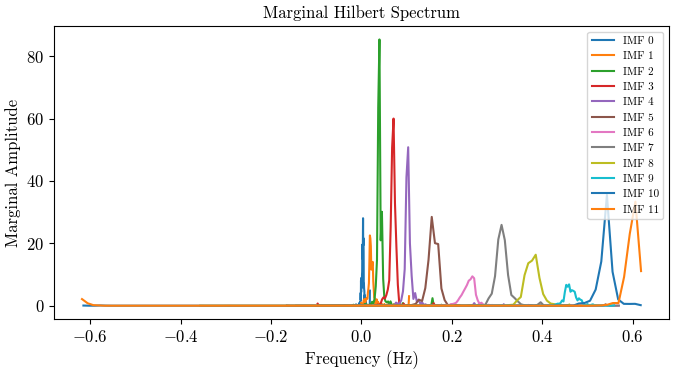

In [32]:
# Plot Marginal Hilbert Spectrum
fig, ax = plt.subplots(figsize=(7.0, 4.0), layout='tight')

for i in range(num_modes):
    hist, bin_edges = np.histogram(instantaneous_frequency_hz[i], bins=100, weights=amplitude_envelope[i])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, hist, label=f"IMF {i}", linewidth=1.5)
    
ax.set_ylabel("Marginal Amplitude")
ax.set_xlabel("Frequency (Hz)")
ax.set_title("Marginal Hilbert Spectrum")
ax.legend(fontsize=8, loc='upper right')

plt.savefig(out_dir / "marginal_hilbert_spectrum.pdf")

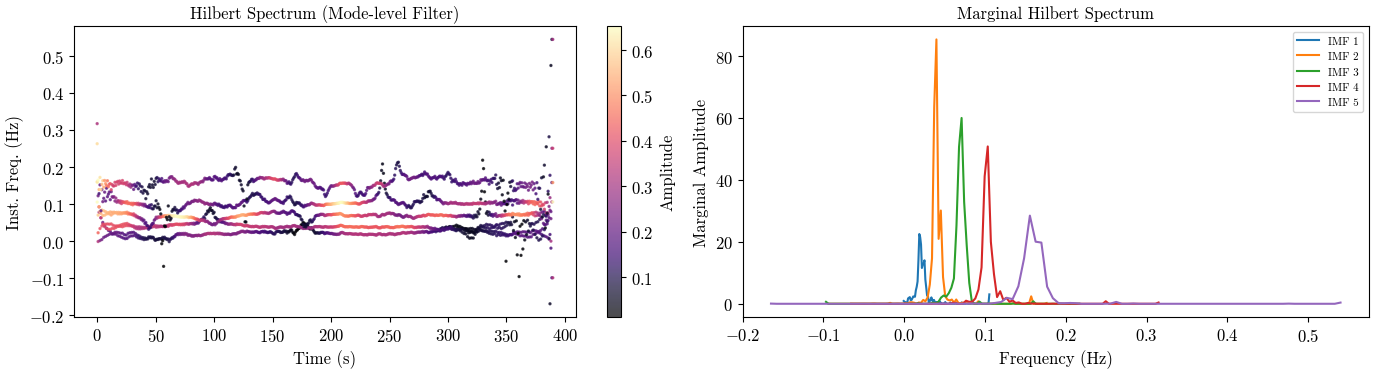

In [33]:
# 1) Filter whole modes by center frequency
valid_modes = np.where((cf_hz >= 0.005) & (cf_hz <= 0.25))[0]

fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.0), layout='tight')

# Hilbert Spectrum
for i in valid_modes:
    im = axes[0].scatter(time_s, instantaneous_frequency_hz[i], c=amplitude_envelope[i], 
                    cmap='magma', s=2, alpha=0.7)

axes[0].set_ylabel("Inst. Freq. (Hz)")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Hilbert Spectrum (Mode-level Filter)")
if 'im' in locals(): fig.colorbar(im, ax=axes[0], label="Amplitude")

# Marginal Hilbert Spectrum
for i in valid_modes:
    hist, bin_edges = np.histogram(instantaneous_frequency_hz[i], bins=100, weights=amplitude_envelope[i])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    axes[1].plot(bin_centers, hist, label=f"IMF {i}", linewidth=1.5)
    
axes[1].set_ylabel("Marginal Amplitude")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_title("Marginal Hilbert Spectrum")
axes[1].legend(fontsize=8, loc='upper right')

plt.savefig(out_dir / "hilbert_mode_filtered.pdf")

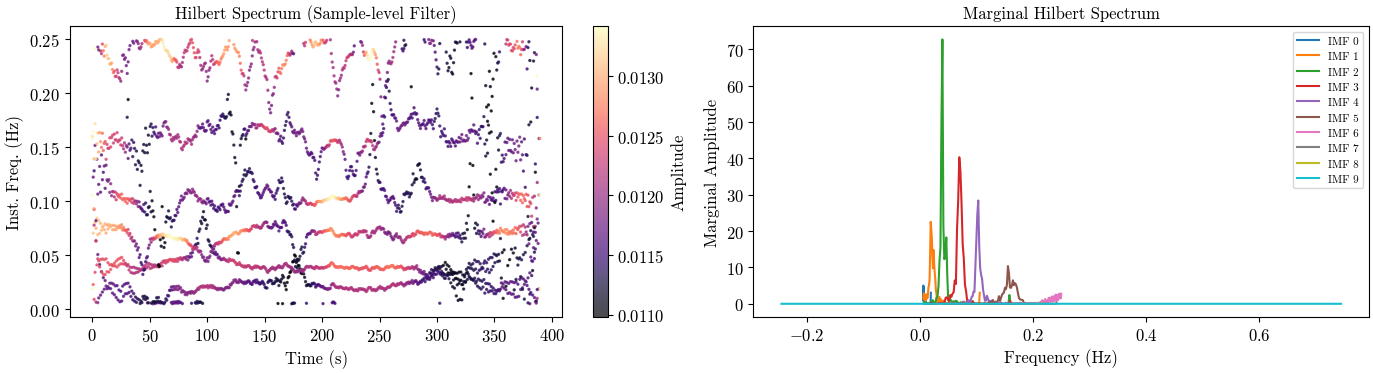

In [34]:
# 2) Filter samples by instantaneous frequency
fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.0), layout='tight')

# Hilbert Spectrum
for i in range(num_modes):
    valid_mask = (instantaneous_frequency_hz[i] >= 0.005) & (instantaneous_frequency_hz[i] <= 0.25)
    if not np.any(valid_mask): continue
    
    im = axes[0].scatter(time_s[valid_mask], instantaneous_frequency_hz[i][valid_mask], 
                         c=amplitude_envelope[i][valid_mask], 
                         cmap='magma', s=2, alpha=0.7)

axes[0].set_ylabel("Inst. Freq. (Hz)")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Hilbert Spectrum (Sample-level Filter)")
if 'im' in locals(): fig.colorbar(im, ax=axes[0], label="Amplitude")

# Marginal Hilbert Spectrum
for i in range(num_modes):
    valid_mask = (instantaneous_frequency_hz[i] >= 0.005) & (instantaneous_frequency_hz[i] <= 0.25)
    if not np.any(valid_mask): continue
        
    hist, bin_edges = np.histogram(instantaneous_frequency_hz[i][valid_mask], bins=100, weights=amplitude_envelope[i][valid_mask])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    axes[1].plot(bin_centers, hist, label=f"IMF {i}", linewidth=1.5)
    
axes[1].set_ylabel("Marginal Amplitude")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_title("Marginal Hilbert Spectrum")
axes[1].legend(fontsize=8, loc='upper right')

plt.savefig(out_dir / "hilbert_sample_filtered.pdf")

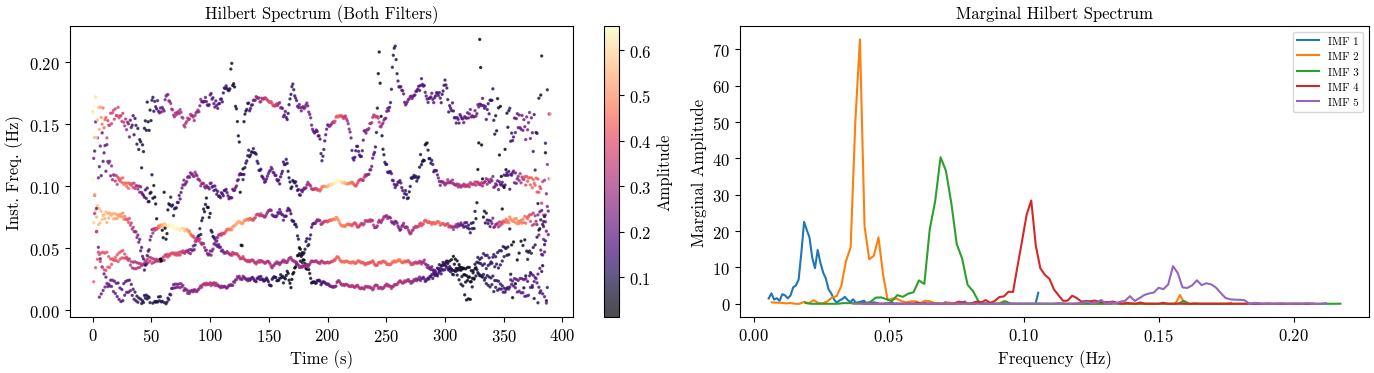

In [35]:
# 3) Filter both: Modes by center frequency, and samples by instantaneous frequency
fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.0), layout='tight')

# valid_modes is defined from step 1
# Hilbert Spectrum
for i in valid_modes:
    valid_mask = (instantaneous_frequency_hz[i] >= 0.005) & (instantaneous_frequency_hz[i] <= 0.25)
    if not np.any(valid_mask): continue
    
    im = axes[0].scatter(time_s[valid_mask], instantaneous_frequency_hz[i][valid_mask], 
                         c=amplitude_envelope[i][valid_mask], 
                         cmap='magma', s=2, alpha=0.7)

axes[0].set_ylabel("Inst. Freq. (Hz)")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Hilbert Spectrum (Both Filters)")
if 'im' in locals(): fig.colorbar(im, ax=axes[0], label="Amplitude")

# Marginal Hilbert Spectrum
for i in valid_modes:
    valid_mask = (instantaneous_frequency_hz[i] >= 0.005) & (instantaneous_frequency_hz[i] <= 0.25)
    if not np.any(valid_mask): continue
        
    hist, bin_edges = np.histogram(instantaneous_frequency_hz[i][valid_mask], bins=100, weights=amplitude_envelope[i][valid_mask])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    axes[1].plot(bin_centers, hist, label=f"IMF {i}", linewidth=1.5)
    
axes[1].set_ylabel("Marginal Amplitude")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_title("Marginal Hilbert Spectrum")
axes[1].legend(fontsize=8, loc='upper right')

plt.savefig(out_dir / "hilbert_both_filtered.pdf")